# P13 — The Aesthetics of Generation
## Stylometric Fingerprints of Large Language Models
**Zeinab Abbas | Università degli Studi di Milano | NLP Course 2025/26**

---
This notebook is a **demonstration and exploration** of the full stylometric pipeline.
It walks through:
1. Data loading and corpus exploration
2. Feature overview and distributions
3. Classification experiment (5-fold CV + permutation test)
4. Per-model stylometric fingerprints
5. Feature sensitivity sweep
6. Robustness: leave-one-genre-out evaluation
7. Error analysis and confusion matrix
8. Key findings summary

## 0. Setup & Imports

In [36]:
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score, LeaveOneGroupOut
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from scipy import stats

# ── Paths ────────────────────────────────────────────────────────────────────
ROOT   = Path('..').resolve()
DATA   = ROOT / 'data'
TABLES = ROOT / 'results' / 'tables'

# ── Colour palette (consistent with paper figures) ───────────────────────────
COLORS = {'chatgpt': '#10A37F', 'gemini': '#4285F4', 'claude': '#C76A47'}
LABELS = {'chatgpt': 'ChatGPT', 'gemini': 'Gemini', 'claude': 'Claude'}

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print('Setup complete.')

Setup complete.


---
## 1. Data Loading & Corpus Exploration

In [37]:
# Load feature matrix
df = pd.read_csv(DATA / 'features.csv')

print(f'Dataset shape: {df.shape}  ({df.shape[0]} texts, {df.shape[1]} columns)')
print(f'\nModels  : {sorted(df["model"].unique())}')
print(f'Genres  : {sorted(df["genre"].unique())}')
print(f'\nTexts per model:')
print(df['model'].value_counts().to_string())
print(f'\nTexts per genre:')
print(df['genre'].value_counts().to_string())

Dataset shape: (105, 173)  (105 texts, 173 columns)

Models  : ['chatgpt', 'claude', 'gemini']
Genres  : ['argumentative', 'creative', 'descriptive', 'dialogue', 'narrative']

Texts per model:
model
chatgpt    35
gemini     35
claude     35

Texts per genre:
genre
narrative        21
argumentative    21
descriptive      21
dialogue         21
creative         21


In [38]:
# Word-count summary per model
print('Average word count per model:')
print(df.groupby('model')['num_words'].agg(['mean','std','min','max']).round(1).to_string())

Average word count per model:
          mean   std  min  max
model                         
chatgpt  261.8  12.1  239  285
claude   253.5   9.8  235  273
gemini   249.0  15.0  222  281


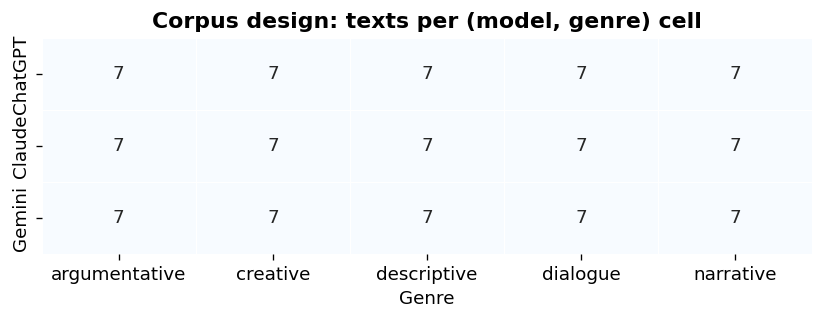

In [39]:
# Balanced factorial design heatmap
pivot = df.groupby(['model','genre']).size().unstack()
fig, ax = plt.subplots(figsize=(7, 2.8))
sns.heatmap(pivot, annot=True, fmt='d', cmap='Blues', linewidths=.5,
            cbar=False, ax=ax, yticklabels=[LABELS[m] for m in pivot.index])
ax.set_title('Corpus design: texts per (model, genre) cell', fontweight='bold')
ax.set_xlabel('Genre'); ax.set_ylabel('')
plt.tight_layout(); plt.show()

---
## 2. Feature Overview

In [40]:
# Identify feature columns (everything except metadata)
META_COLS = ['model', 'genre', 'prompt_id']
feat_cols = [c for c in df.columns if c not in META_COLS]

families = {
    'Lexical diversity' : [c for c in feat_cols if c in ['ttr','mtld','hapax_ratio','avg_word_length','word_length_std','long_word_ratio','yule_k']],
    'Syntactic (POS)'   : [c for c in feat_cols if c.startswith('pos_')],
    'Sentence structure': [c for c in feat_cols if c in ['avg_sent_length','std_sent_length','num_sentences','num_words','max_dep_depth','mean_dep_depth']],
    'Readability'       : [c for c in feat_cols if c in ['flesch_reading_ease','flesch_kincaid_grade','gunning_fog','smog_index','dale_chall']],
    'Discourse markers' : [c for c in feat_cols if c.startswith('discourse_')],
    'Punctuation'       : [c for c in feat_cols if c.startswith('punct_')],
    'Function words'    : [c for c in feat_cols if c.startswith('fw_')],
}

print('Feature families:')
for fam, cols in families.items():
    print(f'  {fam:22s}: {len(cols):3d} features')
print(f'  {"TOTAL":22s}: {sum(len(v) for v in families.values()):3d} features')

Feature families:
  Lexical diversity     :   7 features
  Syntactic (POS)       :  14 features
  Sentence structure    :   6 features
  Readability           :   5 features
  Discourse markers     :   2 features
  Punctuation           :  12 features
  Function words        : 124 features
  TOTAL                 : 170 features


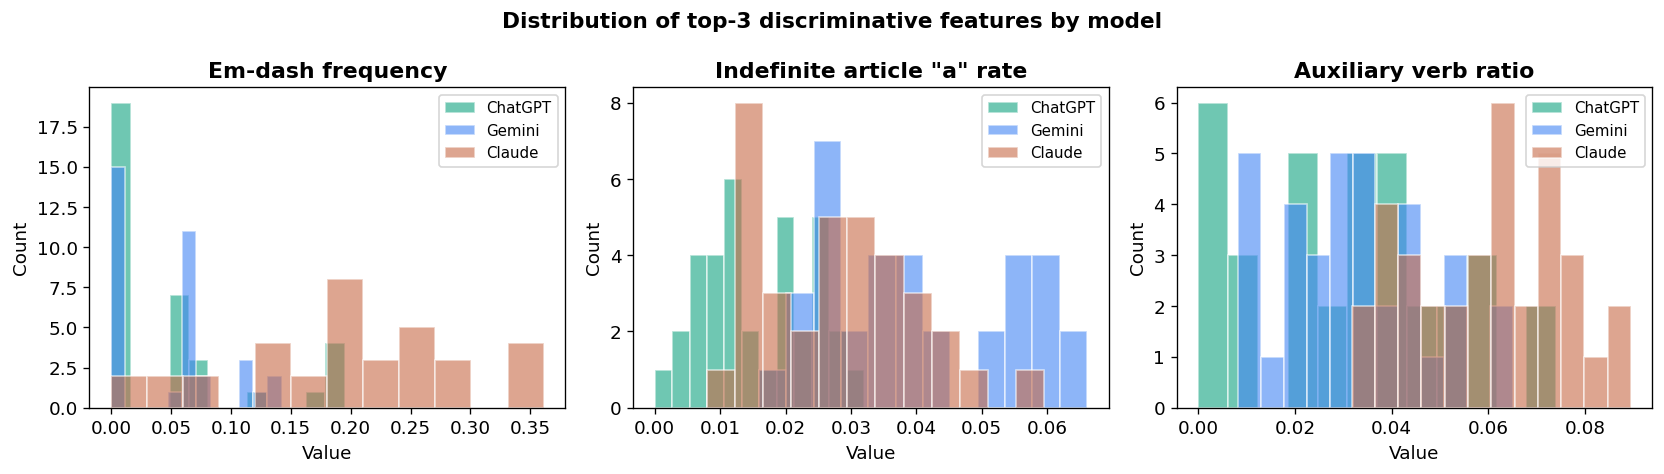

In [41]:
# Distribution of the top-3 discriminative features
top3 = ['punct_dash', 'fw_a', 'pos_aux_ratio']
top3_labels = ['Em-dash frequency', 'Indefinite article "a" rate', 'Auxiliary verb ratio']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, feat, label in zip(axes, top3, top3_labels):
    for model in ['chatgpt', 'gemini', 'claude']:
        vals = df[df['model'] == model][feat]
        ax.hist(vals, bins=12, alpha=0.6, color=COLORS[model], label=LABELS[model], edgecolor='white')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Value'); ax.set_ylabel('Count')
    ax.legend(fontsize=9)
fig.suptitle('Distribution of top-3 discriminative features by model', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 3. Classification Experiment

In [42]:
X = df[feat_cols].values.astype('float64')
y = np.array(df['model'].values, dtype=str)

clf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(C=1.0, max_iter=1000, random_state=42))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_scores = cross_val_score(clf_pipeline, X, y, cv=cv, scoring='accuracy')

print(f'5-Fold CV Accuracy: {fold_scores.mean():.4f} ± {fold_scores.std():.4f}')
print(f'Fold scores       : {[round(s,4) for s in fold_scores]}')
print(f'Chance baseline   : {1/3:.4f}')

5-Fold CV Accuracy: 0.9714 ± 0.0381
Fold scores       : [np.float64(0.9524), np.float64(1.0), np.float64(0.9048), np.float64(1.0), np.float64(1.0)]
Chance baseline   : 0.3333


In [43]:
# Permutation test
np.random.seed(42)
N_PERM = 200
perm_scores = []
for _ in range(N_PERM):
    y_perm = np.random.permutation(y)
    s = cross_val_score(clf_pipeline, X, y_perm, cv=cv, scoring='accuracy').mean()
    perm_scores.append(s)

observed = fold_scores.mean()
p_val = np.mean(np.array(perm_scores) >= observed)
print(f'Observed accuracy : {observed:.4f}')
print(f'Null mean ± std   : {np.mean(perm_scores):.4f} ± {np.std(perm_scores):.4f}')
print(f'Permutation p-val : {p_val:.4f}')
print(f'Z-score           : {(observed - np.mean(perm_scores)) / np.std(perm_scores):.1f}σ above null')

Observed accuracy : 0.9714
Null mean ± std   : 0.3314 ± 0.0593
Permutation p-val : 0.0000
Z-score           : 10.8σ above null


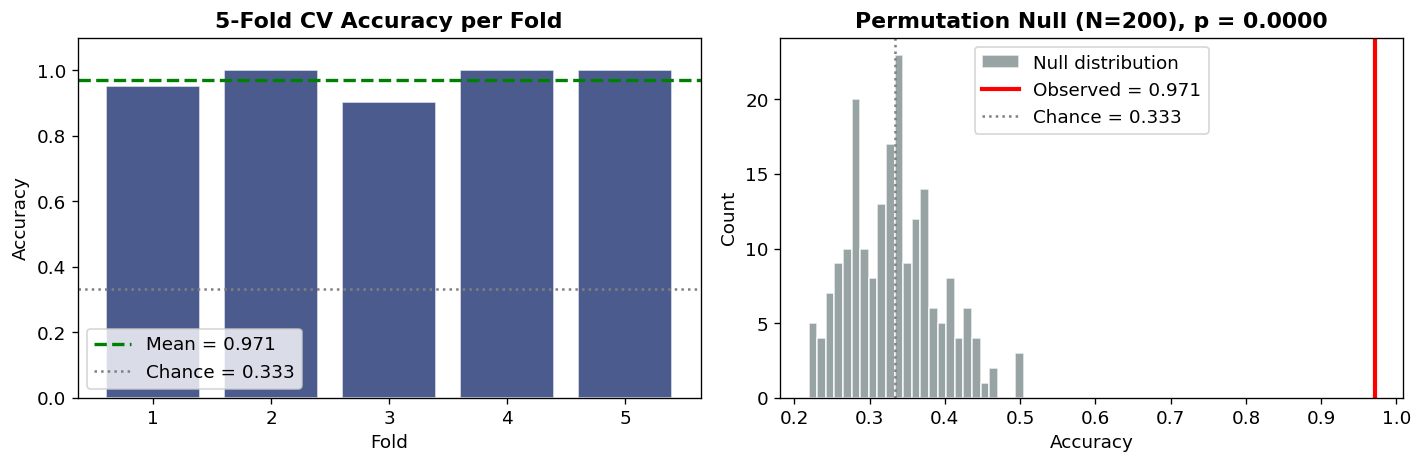

In [44]:
# Visualise fold scores + permutation null
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Fold scores
ax = axes[0]
bars = ax.bar(range(1, 6), fold_scores, color='#2C3E7A', edgecolor='white', alpha=0.85)
ax.axhline(observed, color='green', linewidth=2, linestyle='--', label=f'Mean = {observed:.3f}')
ax.axhline(1/3, color='gray', linewidth=1.5, linestyle=':', label='Chance = 0.333')
ax.set_ylim(0, 1.1); ax.set_xticks(range(1, 6))
ax.set_xlabel('Fold'); ax.set_ylabel('Accuracy')
ax.set_title('5-Fold CV Accuracy per Fold', fontweight='bold')
ax.legend()

# Permutation null
ax = axes[1]
ax.hist(perm_scores, bins=25, color='#7f8c8d', edgecolor='white', alpha=0.8, label='Null distribution')
ax.axvline(observed, color='red', linewidth=2.5, label=f'Observed = {observed:.3f}')
ax.axvline(1/3, color='gray', linewidth=1.5, linestyle=':', label='Chance = 0.333')
ax.set_xlabel('Accuracy'); ax.set_ylabel('Count')
ax.set_title(f'Permutation Null (N={N_PERM}), p = {p_val:.4f}', fontweight='bold')
ax.legend()

plt.tight_layout(); plt.show()

---
## 4. Per-Model Stylometric Fingerprints

In [45]:
# Load ANOVA results and select top-10 features
anova_df = pd.read_csv(TABLES / 'feature_anova.csv')
top10 = anova_df.nlargest(10, 'anova_F')['feature'].tolist()

print('Top-10 ANOVA features:')
print(anova_df.nlargest(10, 'anova_F')[['feature','anova_F','anova_p_holm']].to_string(index=False))

Top-10 ANOVA features:
        feature   anova_F  anova_p_holm
     punct_dash 50.658007  8.959976e-14
           fw_a 39.144842  4.092426e-11
  pos_aux_ratio 29.778448  1.094757e-08
           mtld 26.080546  1.187440e-07
  pos_adv_ratio 25.024155  2.385917e-07
    punct_comma 25.009495  2.394985e-07
            ttr 24.777136  2.782757e-07
        fw_that 21.693288  2.301742e-06
    hapax_ratio 19.680955  9.575712e-06
std_sent_length 19.613022  9.994939e-06


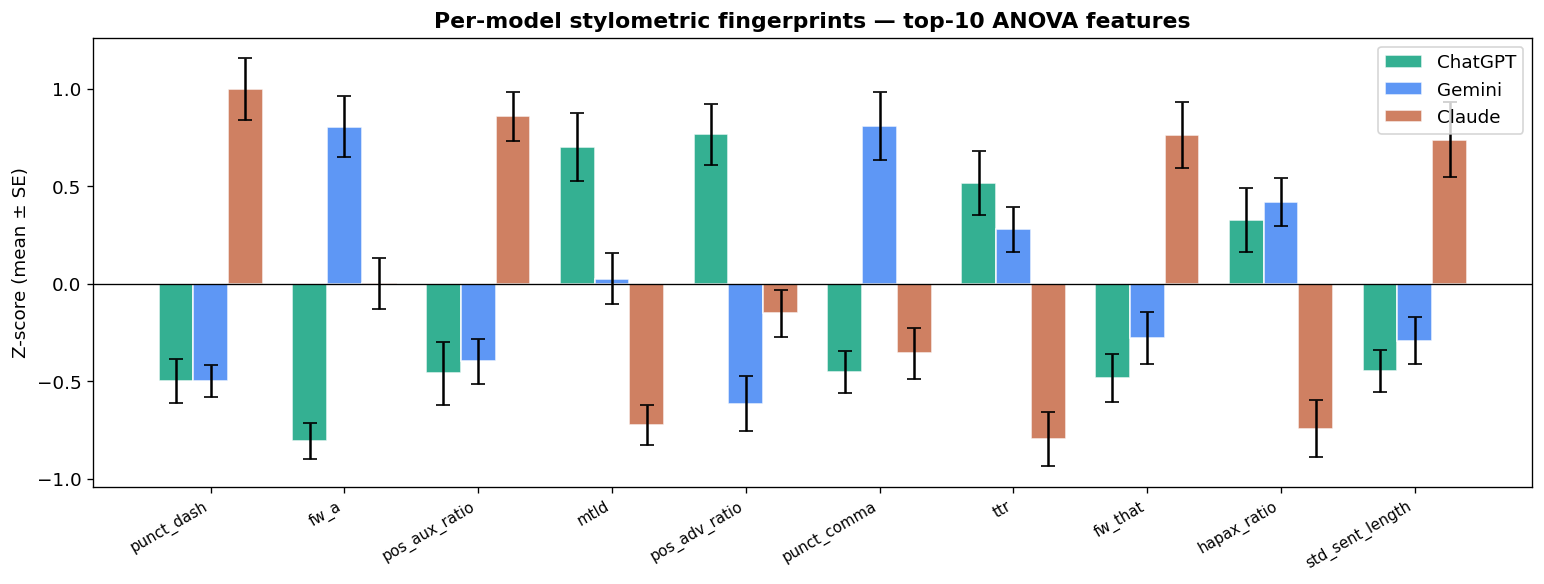

In [35]:
# Z-score the top features and plot grouped bar chart
from sklearn.preprocessing import StandardScaler

sub = df[['model'] + top10].copy()
sub[top10] = StandardScaler().fit_transform(sub[top10])
means = sub.groupby('model')[top10].mean()
sems  = sub.groupby('model')[top10].sem()

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(top10))
width = 0.26
for i, model in enumerate(['chatgpt', 'gemini', 'claude']):
    offsets = x + (i - 1) * width
    ax.bar(offsets, means.loc[model], width, yerr=sems.loc[model],
           color=COLORS[model], label=LABELS[model], alpha=0.85,
           capsize=4, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(top10, rotation=30, ha='right', fontsize=9)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Z-score (mean ± SE)')
ax.set_title('Per-model stylometric fingerprints — top-10 ANOVA features', fontweight='bold')
ax.legend()
plt.tight_layout(); plt.show()

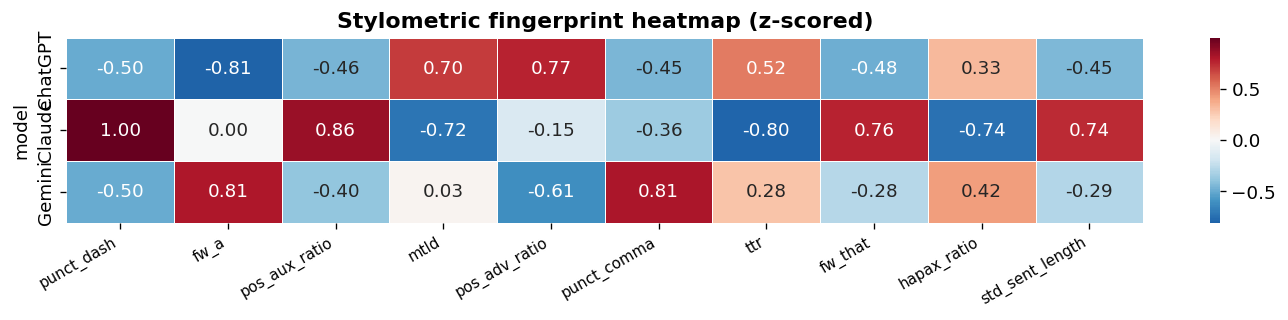

In [46]:
# Heatmap view of fingerprints
fig, ax = plt.subplots(figsize=(12, 2.8))
heatmap_data = means[top10]
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax,
            yticklabels=[LABELS[m] for m in heatmap_data.index])
ax.set_title('Stylometric fingerprint heatmap (z-scored)', fontweight='bold')
ax.set_xlabel('')
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.tight_layout(); plt.show()

---
## 5. Feature Sensitivity Sweep

In [ ]:
# Rank features by ANOVA F-statistic and sweep over k
ranked_features = anova_df.sort_values('anova_F', ascending=False)['feature'].tolist()
# Keep only features present in data
ranked_features = [f for f in ranked_features if f in feat_cols]

k_values = [1, 3, 5, 10, 20, 35, 50, 75, 100, 150, len(ranked_features)]
k_values = [k for k in k_values if k <= len(ranked_features)]

sweep_scores = []
for k in k_values:
    X_k = df[ranked_features[:k]].values.astype('float64')
    scores = cross_val_score(clf_pipeline, X_k, y, cv=cv, scoring='accuracy')
    sweep_scores.append(scores.mean())
    print(f'k={k:4d}  →  CV accuracy = {scores.mean():.4f}')

KeyError: 'f_stat'

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(k_values, sweep_scores, 'o-', color='#2C3E7A', linewidth=2, markersize=7)
ax.axhline(1/3, color='gray', linestyle=':', label='Chance (33.3%)')
ax.axhline(observed, color='green', linestyle='--', alpha=0.6, label=f'Full-feature ({observed:.3f})')
ax.set_xlabel('Number of features (k)')
ax.set_ylabel('5-fold CV accuracy')
ax.set_title('Accuracy vs. feature-set size', fontweight='bold')
ax.set_ylim(0.2, 1.05)
ax.legend()

ax = axes[1]
gain = [s - 1/3 for s in sweep_scores]
ax.bar(range(len(k_values)), gain, color='#10A37F', edgecolor='white', alpha=0.85)
ax.set_xticks(range(len(k_values)))
ax.set_xticklabels([str(k) for k in k_values], rotation=45)
ax.set_xlabel('Number of features (k)')
ax.set_ylabel('Gain over chance')
ax.set_title('Absolute gain over 33.3% chance baseline', fontweight='bold')

plt.tight_layout(); plt.show()

---
## 6. Robustness — Leave-One-Genre-Out

In [ ]:
genres = df['genre'].unique()
logo_results = {}

for genre in genres:
    train_mask = df['genre'] != genre
    test_mask  = df['genre'] == genre
    X_train, y_train = X[train_mask], y[train_mask]
    X_test,  y_test  = X[test_mask],  y[test_mask]
    clf_pipeline.fit(X_train, y_train)
    acc = clf_pipeline.score(X_test, y_test)
    logo_results[genre] = acc
    print(f'Hold-out genre: {genre:15s}  →  accuracy = {acc:.4f}')

mean_logo = np.mean(list(logo_results.values()))
print(f'\nMean LOGO accuracy: {mean_logo:.4f}  (chance = 0.333)')

Hold-out genre: narrative        →  accuracy = 0.9524
Hold-out genre: argumentative    →  accuracy = 0.9048
Hold-out genre: descriptive      →  accuracy = 0.9048
Hold-out genre: dialogue         →  accuracy = 1.0000
Hold-out genre: creative         →  accuracy = 0.9048

Mean LOGO accuracy: 0.9333  (chance = 0.333)


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
genres_sorted = sorted(logo_results, key=logo_results.get)
values = [logo_results[g] for g in genres_sorted]
bar_colors = ['#E74C3C' if v < 0.75 else '#2C3E7A' for v in values]
ax.barh(genres_sorted, values, color=bar_colors, edgecolor='white', alpha=0.85)
ax.axvline(1/3, color='gray', linestyle=':', linewidth=1.5, label='Chance (33.3%)')
ax.axvline(mean_logo, color='green', linestyle='--', linewidth=1.5, label=f'Mean LOGO ({mean_logo:.2f})')
ax.set_xlabel('Accuracy on held-out genre')
ax.set_title('Leave-One-Genre-Out accuracy', fontweight='bold')
ax.set_xlim(0, 1.05)
ax.legend()
# Annotate bars
for i, (g, v) in enumerate(zip(genres_sorted, values)):
    ax.text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=10)
plt.tight_layout(); plt.show()

---
## 7. Error Analysis — Confusion Matrix

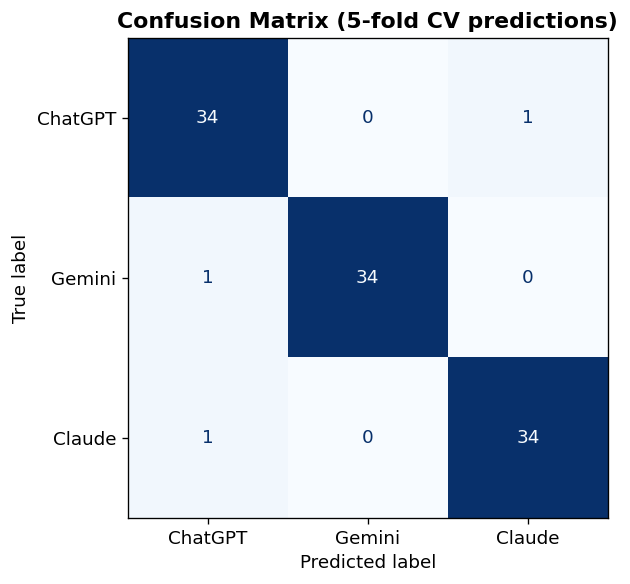


Classification report:
              precision    recall  f1-score   support

     ChatGPT       0.94      0.97      0.96        35
      Gemini       0.97      0.97      0.97        35
      Claude       1.00      0.97      0.99        35

    accuracy                           0.97       105
   macro avg       0.97      0.97      0.97       105
weighted avg       0.97      0.97      0.97       105



In [ ]:
from sklearn.model_selection import cross_val_predict

y_pred = cross_val_predict(clf_pipeline, X, y, cv=cv)
cm = confusion_matrix(y, y_pred, labels=['chatgpt', 'gemini', 'claude'])

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['ChatGPT', 'Gemini', 'Claude'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix (5-fold CV predictions)', fontweight='bold')
plt.tight_layout(); plt.show()

print('\nClassification report:')
print(classification_report(y, y_pred,
      target_names=['ChatGPT', 'Gemini', 'Claude']))

---
## 8. Key Findings Summary

In [ ]:
# Concrete numbers for the three models on their signature features
summary = df.groupby('model').agg(
    MTLD        = ('mtld',        'mean'),
    TTR         = ('ttr',         'mean'),
    Dash_freq   = ('punct_dash',  'mean'),
    Comma_freq  = ('punct_comma', 'mean'),
    Article_a   = ('fw_a',        'mean'),
    Adverb_rate = ('pos_adv_ratio','mean'),
    Avg_words   = ('num_words',   'mean'),
).round(3)
summary.index = [LABELS[m] for m in summary.index]
print('Per-model signature statistics:')
print(summary.to_string())

In [ ]:
print('='*60)
print('  SUMMARY OF KEY FINDINGS')
print('='*60)
print(f"""
Classification:
  • 5-fold CV accuracy : {fold_scores.mean():.1%}  (chance = 33.3%)
  • Permutation p-value: {p_val:.4f}
  • Misclassified texts: {(y != y_pred).sum()} out of {len(y)}

Model fingerprints:
  • Claude   → highest em-dash usage ({df[df.model=='claude']['punct_dash'].mean():.3f}/char)
  • Gemini   → highest comma rate    ({df[df.model=='gemini']['punct_comma'].mean():.3f}/char)
              → highest article 'a'  ({df[df.model=='gemini']['fw_a'].mean():.3f} token rate)
  • ChatGPT  → highest lexical div.  (MTLD = {df[df.model=='chatgpt']['mtld'].mean():.1f})
              → highest adverb rate  ({df[df.model=='chatgpt']['pos_adv_ratio'].mean():.3f})

Robustness:
  • Mean LOGO accuracy : {mean_logo:.1%}  (well above chance)
  • Gemini never misclassified in CV
  • Signal appears with just 5 features (88%+ accuracy)
""")

  SUMMARY OF KEY FINDINGS

Classification:
  • 5-fold CV accuracy : 97.1%  (chance = 33.3%)
  • Permutation p-value: 0.0000
  • Misclassified texts: 3 out of 105

Model fingerprints:
  • Claude   → highest em-dash usage (0.197/char)
  • Gemini   → highest comma rate    (1.498/char)
              → highest article 'a'  (0.040 token rate)
  • ChatGPT  → highest lexical div.  (MTLD = 195.7)
              → highest adverb rate  (0.083)

Robustness:
  • Mean LOGO accuracy : 93.3%  (well above chance)
  • Gemini never misclassified in CV
  • Signal appears with just 5 features (88%+ accuracy)

